#### Tumor Diagnosis

Find the best value of alpha in SVM model that links features (tumor size, texture and more) with its nature, benign or malign.  
It is a Linear SVM model algorithm that uses linear model SGD classifier with hinge loss, L2 regularization and alpha using gradient descent algorithm on hingle loss.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 60 #

In [8]:
from sklearn import datasets, preprocessing, linear_model, model_selection as ms

In [9]:
def polynomial_kernel(X, Y, c, p):
    return ((X @ Y.T) + c)**p

def rbf_kernel(X, Y, gamma):
    from scipy.spatial import distance
    return np.exp(- gamma * distance.cdist(X, Y, metric='sqeuclidean'))

In [10]:
tumor_data = datasets.load_breast_cancer()
y, X = tumor_data.target, tumor_data.data
X = preprocessing.scale(X)

Text(0, 0.5, 'tumor texture')

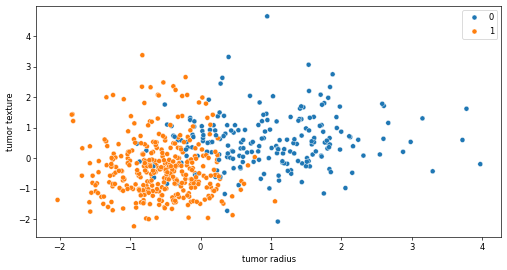

In [15]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.xlabel('tumor radius')
plt.ylabel('tumor texture')

In [17]:
alpha = np.arange(1e-15, 1, 0.005)
val_scores = np.zeros((len(alpha), 1))

for i in range(len(alpha)):
    model = linear_model.SGDClassifier(loss='hinge', penalty='l2', alpha=alpha[i])
    score = ms.cross_val_score(model, X, y, cv=5)
    val_scores[i] = score.mean()

Text(0, 0.5, 'Mean CV accuracy - validation score')

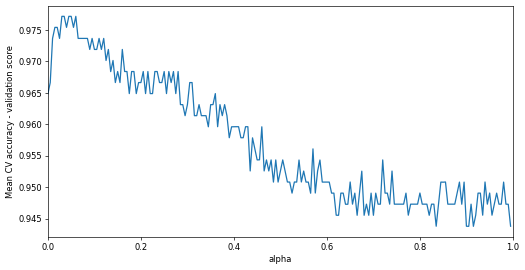

In [18]:
plt.plot(alpha, val_scores)
plt.xlim(0,1)
plt.xlabel('alpha')
plt.ylabel('Mean CV accuracy - validation score')

In [19]:
ind = np.argmax(val_scores)
best_alpha = alpha[ind]
print(best_alpha)

0.030000000000000998


Text(0, 0.5, 'Mean CV accuracy - validation score')

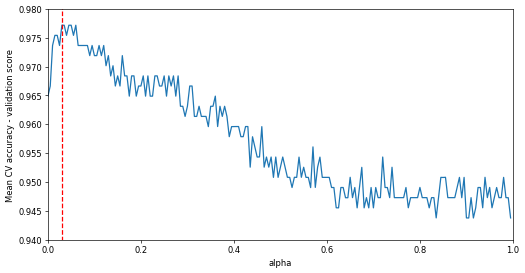

In [20]:
plt.plot(alpha, val_scores)
y_values_for_line = np.arange(0,1.1, 0.1)
plt.plot(np.ones(11)*best_alpha, y_values_for_line, 'r--')
plt.xlim(0,1)
plt.ylim(0.94, 0.98)
plt.xlabel('alpha')
plt.ylabel('Mean CV accuracy - validation score')

In [21]:
model_best = linear_model.SGDClassifier(loss='hinge', penalty='l2', alpha=best_alpha)
model_trained = model_best.fit(X, y)
model_trained.score(X, y)

0.9806678383128296

-1.216733259445962


Text(0, 0.5, 'tumor texture')

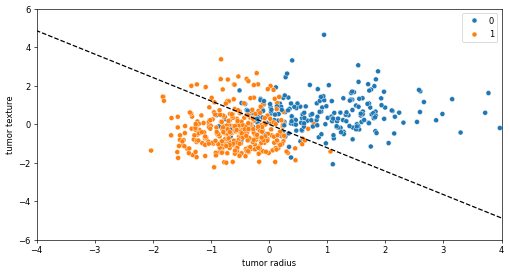

In [22]:
slope = model_trained.coef_[0, 1]/-model_trained.coef_[0, 0]
print(slope)
intercept = model_trained.intercept_[0]
x1 = np.arange(-10, 10, 0.5)
y1 = slope*x1 #+ intercept
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.plot(x1, y1, '--k')
plt.xlim(-4, 4)
plt.ylim(-6, 6)
plt.xlabel('tumor radius')
plt.ylabel('tumor texture')

### Kernel Perceptron

In [ ]:
def kernel_perceptron(X, y, T, kernel_func, **kernel_params):
    n_samples = X.shape[0]
    alpha = np.zeros(n_samples)
    b = 0 # bias term
    errors = []
    num_mistakes_per_epoch = []

    for t in range(T):
        mistakes = 0
        shuffled_indices = np.random.permutation(n_samples)
        for i in shuffled_indices:
            # Calculate the decision function f(x) = sum(alpha_j * y_j * K(x_j, x)) + b
            # This is done by computing K(X_train, X_i) for all j, then dot product with alpha*y
            decision_function = 0
            for j in range(n_samples):
                if alpha[j] > 0:
                    decision_function += alpha[j] * y[j] * kernel_func(X[j].reshape(1, -1), X[i].reshape(1, -1), **kernel_params)[0,0]
            decision_function += b

            # Make a prediction
            prediction = np.sign(decision_function)

            # Update if misclassified
            if prediction != y[i]:
                alpha[i] += 1  # Increment alpha for the misclassified point
                b += y[i]    # Update bias
                mistakes += 1
        errors.append(mistakes)
        num_mistakes_per_epoch.append(mistakes)
        if mistakes == 0:
            break # Converged

    return alpha, b, errors, num_mistakes_per_epoch

In [ ]:
X_kp = X[:, :2] # Using only the first two features for visualization
y_kp = np.where(y == 0, -1, 1) # Convert y to -1, 1 for perceptron

degrees = [1, 2, 3]
results_poly = {}

for d in degrees:
    print(f"\nRunning Kernel Perceptron with Polynomial Kernel (degree={d})")
    # c=1, p=d as per user request in polynomial kernel def
    alpha_poly, b_poly, errors_poly, _ = kernel_perceptron(X_kp, y_kp, T=100, kernel_func=polynomial_kernel, c=1, p=d)
    results_poly[d] = {'alpha': alpha_poly, 'b': b_poly, 'errors': errors_poly}
    print(f"Final errors for degree {d}: {errors_poly[-1]}")


Running Kernel Perceptron with Polynomial Kernel (degree=1)
Final errors for degree 1: 93

Running Kernel Perceptron with Polynomial Kernel (degree=2)
Final errors for degree 2: 88

Running Kernel Perceptron with Polynomial Kernel (degree=3)
Final errors for degree 3: 84


In [ ]:
def predict_kernel_perceptron(X_train, y_train, alpha, b, kernel_func, kernel_params, X_test):
    predictions = []
    for x_new in X_test:
        decision_function = 0
        for j in range(len(X_train)):
            if alpha[j] > 0:
                decision_function += alpha[j] * y_train[j] * kernel_func(X_train[j].reshape(1, -1), x_new.reshape(1, -1), **kernel_params)[0,0]
        decision_function += b
        predictions.append(np.sign(decision_function))
    return np.array(predictions)

def plot_decision_boundary_kernel_perceptron(X, y, alpha, b, kernel_func, kernel_params, title):
    plt.figure(figsize=(8, 6), dpi=60)
    # Create a meshgrid to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict over the meshgrid
    Z = predict_kernel_perceptron(X, y, alpha, b, kernel_func, kernel_params, np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', marker='o')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

##### Polynomial Kernel Visualizations

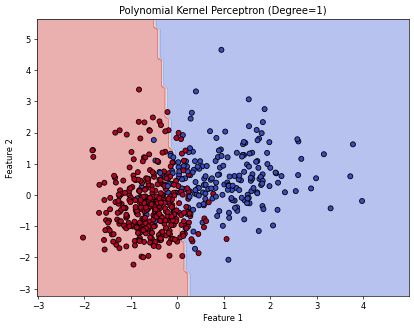

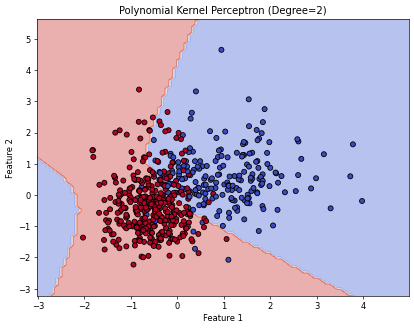

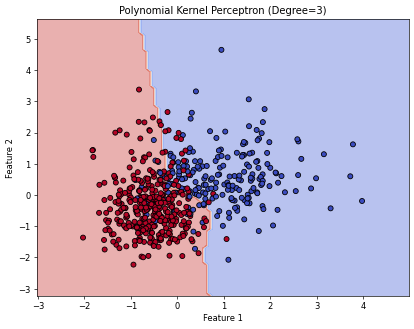

In [ ]:
for d in degrees:
    alpha_poly = results_poly[d]['alpha']
    b_poly = results_poly[d]['b']
    plot_decision_boundary_kernel_perceptron(
        X_kp, y_kp, alpha_poly, b_poly, polynomial_kernel, {'c': 1, 'p': d},
        f'Polynomial Kernel Perceptron (Degree={d})'
    )

##### Exponential (RBF) Kernel


Running Kernel Perceptron with RBF Kernel (gamma=0.1)
Final errors for gamma 0.1: 83

Running Kernel Perceptron with RBF Kernel (gamma=1.0)
Final errors for gamma 1.0: 69

Running Kernel Perceptron with RBF Kernel (gamma=10.0)
Final errors for gamma 10.0: 39

Best RBF gamma: 10.0 with 39 errors


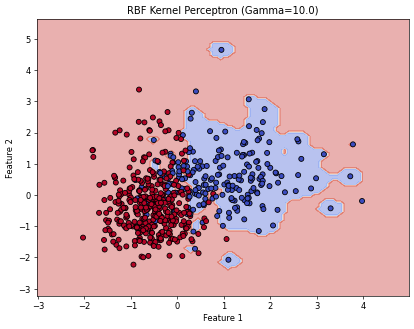

In [ ]:
# For RBF kernel, we need to choose a gamma parameter. Let's try a few values.
# A common heuristic for gamma is 1 / (2 * sigma^2). Let's start with a general value.
gamma_values = [0.1, 1.0, 10.0]
results_rbf = {}

for gamma in gamma_values:
    print(f"\nRunning Kernel Perceptron with RBF Kernel (gamma={gamma})")
    alpha_rbf, b_rbf, errors_rbf, _ = kernel_perceptron(X_kp, y_kp, T=100, kernel_func=rbf_kernel, gamma=gamma)
    results_rbf[gamma] = {'alpha': alpha_rbf, 'b': b_rbf, 'errors': errors_rbf}
    print(f"Final errors for gamma {gamma}: {errors_rbf[-1]}")

# Choose the gamma with the fewest errors for visualization
best_gamma = min(results_rbf, key=lambda g: results_rbf[g]['errors'][-1])
print(f"\nBest RBF gamma: {best_gamma} with {results_rbf[best_gamma]['errors'][-1]} errors")

plot_decision_boundary_kernel_perceptron(
    X_kp, y_kp, results_rbf[best_gamma]['alpha'], results_rbf[best_gamma]['b'], rbf_kernel, {'gamma': best_gamma},
    f'RBF Kernel Perceptron (Gamma={best_gamma})'
)